## Import Libraries

In [1]:
import pandas as pd
import numpy as np
import json

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

## Load Dataset Again

In [2]:
data = []

with open("../data/resumes_dataset.jsonl","r",encoding="utf-8") as file:
    for line in file:
        data.append(json.loads(line))

df = pd.DataFrame(data)

print(df.shape)

(3500, 12)


In [3]:
df.head()

,ResumeID,Category,Name,Email,Phone,Location,Summary,Skills,Experience,Education,Text,Source
0,REAL_0001,Java Developer,Chad Griffin,contact@email.com,94105 555 4321000 10 ...,"City, State",jessica claire montgomery street san francisco...,"Python, SQL, Git, Linux",jessica claire montgomery street san francisco...,Computer Science degree,jessica claire montgomery street san francisco...,ResumeAtlas
1,REAL_0002,Java Developer,Melinda Thomas,contact@email.com,17994568777 2017 2018 20152016 3 ...,"City, State",jared arthur maica java developer 17994568777 ...,"Python, SQL, Git, Linux",jared arthur maica java developer 17994568777 ...,Computer Science degree,jared arthur maica java developer 17994568777 ...,ResumeAtlas
2,REAL_0003,Java Developer,Shannon Mccarthy,contact@email.com,9 555 4321000 94105 8 ...,"City, State",jessica claire 9 resumesampleexamplecom 555 43...,"Python, SQL, Git, Linux",jessica claire 9 resumesampleexamplecom 555 43...,Computer Science degree,jessica claire 9 resumesampleexamplecom 555 43...,ResumeAtlas
3,REAL_0004,Java Developer,Christine Kelley,contact@email.com,9 555 4321000 94105 5 ...,"City, State",jessica claire 9 resumesampleexamplecom 555 43...,"Python, SQL, Git, Linux",jessica claire 9 resumesampleexamplecom 555 43...,Computer Science degree,jessica claire 9 resumesampleexamplecom 555 43...,ResumeAtlas
4,REAL_0005,Java Developer,Karen Holt,contact@email.com,100 10 4321000 ...,"City, State",jessica claire 100 montgomery st 10th floor xx...,"Python, SQL, Git, Linux",jessica claire 100 montgomery st 10th floor xx...,Computer Science degree,jessica claire 100 montgomery st 10th floor xx...,ResumeAtlas


## Statistical Overview

In [4]:
df.describe(include="all")

,ResumeID,Category,Name,Email,Phone,Location,Summary,Skills,Experience,Education,Text,Source
count,3500,3500,3500,3500,3500,3500,3500,3500,3500,3500,3500,3500
unique,3500,36,3410,1161,3279,1164,2226,919,3262,1160,3304,2
top,REAL_0001,Java Developer,Michael Williams,contact@email.com,555-123-4567,"City, State",Experienced Software Developer with 9+ years b...,"Python, SQL, Git, Linux",ron phoenix blockchain developer 15491295157 d...,Computer Science degree,jessica claire montgomery street san francisco...,ResumeAtlas
freq,1,200,4,2337,17,2337,20,2337,5,2337,4,2337


## Category Distribution

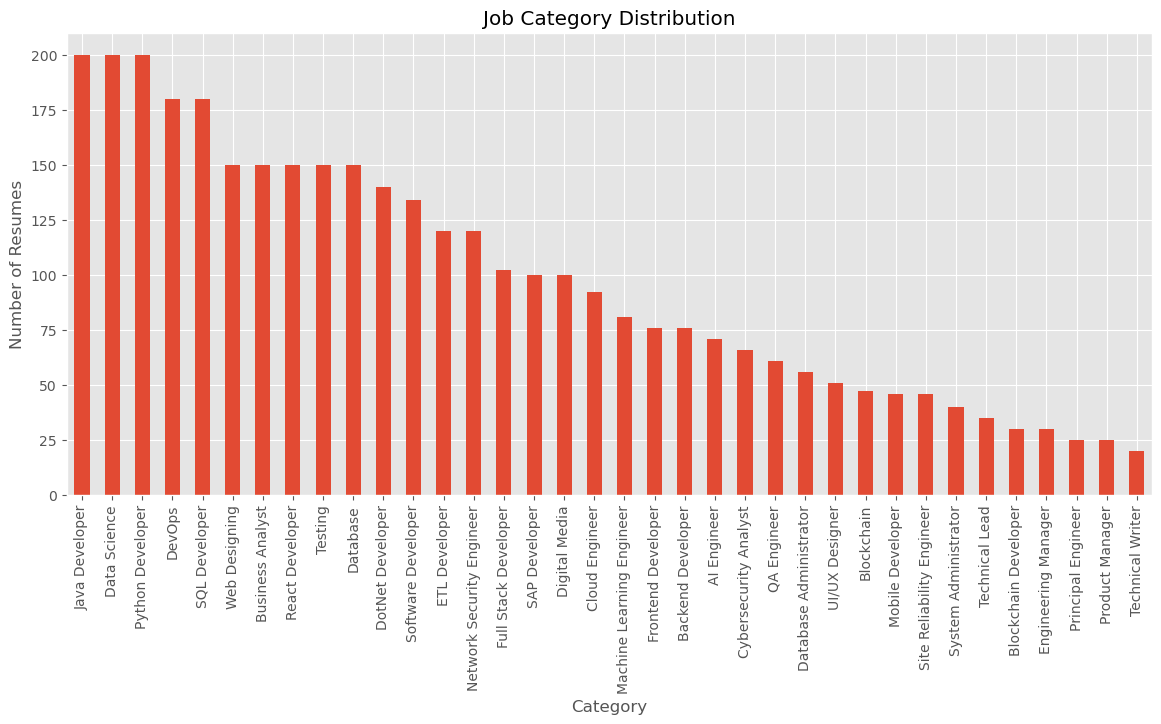

In [5]:
plt.figure(figsize=(14,6))

df["Category"].value_counts().plot(kind="bar")

plt.title("Job Category Distribution")
plt.xlabel("Category")
plt.ylabel("Number of Resumes")

plt.xticks(rotation=90)

plt.show()

## Source Distribution

In [7]:
df["Source"].value_counts()

Source
ResumeAtlas    2337
Synthetic      1163
Name: count, dtype: int64

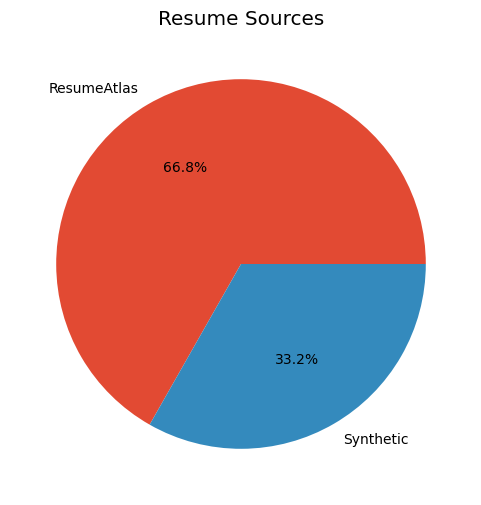

In [8]:
plt.figure(figsize=(6,6))

df["Source"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.ylabel("")

plt.title("Resume Sources")

plt.show()

## Resume Length

In [9]:
df["Resume_Length"] = df["Text"].apply(lambda x: len(str(x).split()))

df["Resume_Length"].describe()

count    3500.000000
mean      423.564857
std       360.679658
min        28.000000
25%       196.000000
50%       257.000000
75%       577.000000
max      6554.000000
Name: Resume_Length, dtype: float64

## Resume Length Distribution

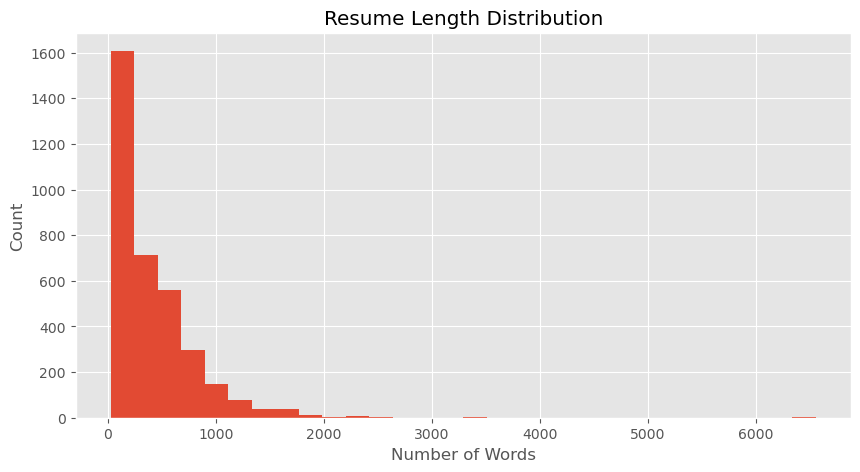

In [10]:
plt.figure(figsize=(10,5))

plt.hist(df["Resume_Length"], bins=30)

plt.title("Resume Length Distribution")

plt.xlabel("Number of Words")

plt.ylabel("Count")

plt.show()

## Duplicate Check

In [12]:
duplicates = df.duplicated(subset=["Text"]).sum()

print("Duplicate Resumes :", duplicates)

Duplicate Resumes : 196


## Top 20 Skills

In [13]:
all_skills = []

for skills in df["Skills"]:
    skills = str(skills).split(",")

    for skill in skills:
        all_skills.append(skill.strip())

In [14]:
skill_df = pd.Series(all_skills)

skill_df.value_counts().head(20)

Git              3242
Python           3046
Linux            3005
SQL              2946
Docker            657
AWS               641
Agile             613
JavaScript        555
REST API          408
Scrum             351
Microservices     344
PostgreSQL        336
Node.js           319
Java              292
React             292
MongoDB           271
HTML              169
Express           166
CSS               165
GCP               163
Name: count, dtype: int64

## Plot Top Skills

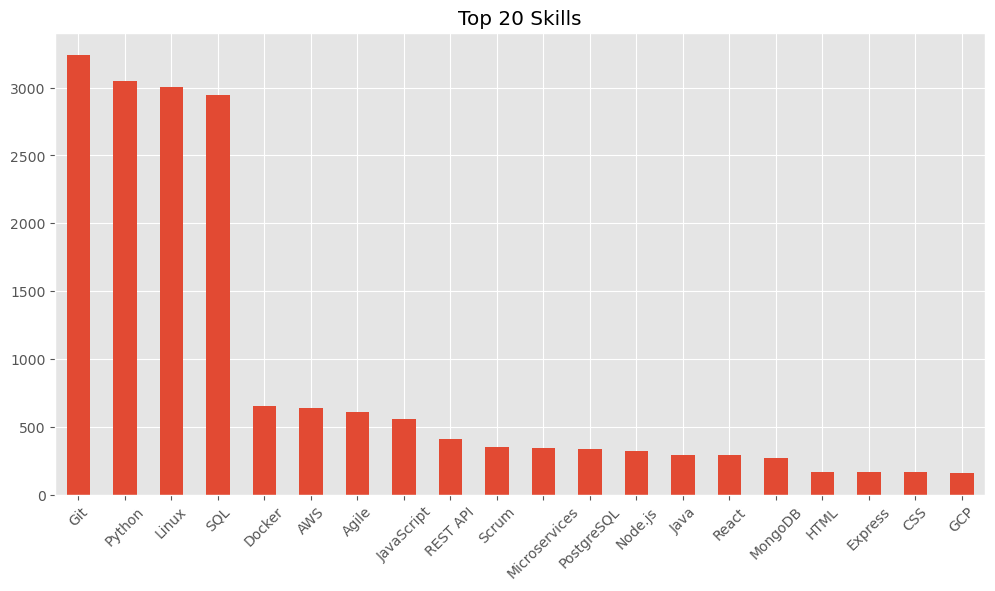

In [15]:
plt.figure(figsize=(12,6))

skill_df.value_counts().head(20).plot(kind="bar")

plt.title("Top 20 Skills")

plt.xticks(rotation=45)

plt.show()

## Resume Categories Count

In [16]:
print("Total Categories :", df["Category"].nunique())

Total Categories : 36


## Conclusion

- Dataset contains 3500 resumes.
- Dataset is balanced across job categories.
- Most resumes contain 200–800 words.
- Python, SQL, Git, Linux, Docker and AWS are the most common skills.
- Dataset is suitable for Resume Classification and ATS Scoring.